# Notebook 5- Clinical NLP Pipeline

This notebook evaluates several NLP approaches for extracting predictive information from free text clinical documentation related to postoperative infection risk.

The pipeline uses two primary text fields:
- `disease_history`
- `surgical_procedure_desc`

This notebook includes: 

1. Textual Exploratory analysis
2. Temporal eligibility checks for postoperative text
3. Rule-based extraction of dempographic and comorbidity features from `disease_history`
4. TF-IDF models using separate vectorizers for each text field.
5. Logistic Regression and XGBoost baselines
6. Local Llama inference for generation of an infection-risk score and structured clinical indicators.
7. Comparison of the evaluated NLP approaches

## Setup: offline environment + project constants


In [ ]:
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

import re
import json
import time
import math
import difflib
from pathlib import Path
from collections import Counter
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- shared constants (unchanged values from the original notebook,
# so anything already written about the split in the report stays valid) ---
RANDOM_STATE = 42

TEXT_COLS = [
    "disease_history",
    "surgical_procedure_desc",
]  

TEST_POS_FRACTION = 0.2
TEST_NEG_POS_RATIO = 10
OPTION_B_N_NEGATIVES = 5000

# Unique surgical-record identifier, used as the Llama cache key so a
# resumed run matches rows correctly.
CASE_ID_COL = "case_number"

# ---- output paths - fill in for the closed environment --------------------
REPORTS_DIR = r"H:/27 project/models/NLP_visualization"          
LLAMA_CACHE_PATH = r"H:/27 project/models/llama_outputs_cache_llama33_final.csv"
LLAMA_FEATURES_PATH = r"H:/27 project/models/llama_features.csv"

# ---- Llama local access -----------------------------------------------------
LLAMA_MODEL_NAME = "llama3.3:70b"

# Supported values: "ollama_http" - only call_llama_api()'s 
# two backend functions need to change if IT describes a different serving stack
LLAMA_BACKEND = "ollama_http"
LLAMA_OLLAMA_URL = "http://10.25.1.58:11434/api/chat"         

LLAMA_TIMEOUT_SECONDS = 200
LLAMA_MAX_RETRIES = 0
LLAMA_CHECKPOINT_EVERY = 25   # append to the on-disk cache every N new rows, so an interrupted run loses at most N rows

# Safer defaults: start on the (small) shared TEST split only, and cap the very first run to a smoke test. 
# Widen only after confirming the endpoint, the JSON parsing, and Hebrew handling all look right on a small sample.
LLAMA_RUN_SCOPE = "test_only" 
LLAMA_MAX_ROWS = 100

CLEANED_DATA_PATH = r"H:\27 project\cleaning\cleaning_outputs\cohort_restricted.xlsx" 
cleaned_df = pd.read_excel(CLEANED_DATA_PATH)
final_cases = cleaned_df["case_number"].dropna().unique()


## Stage 0: build the infection label, load the data

The raw dataset is loaded and the binary infection outcome is constructed.


`build_infection_label`: a case is labeled as `infection=1` if **either** `added1_infection diagnosis` **or** `clinical SSI diagnosis` is non-empty (site is sometimes documented even when the diagnosis field itself was left blank, and vice versa).


In [ ]:
def build_infection_label(df_input, diagnosis_col="added1_infection diagnosis",
                           site_col="clinical SSI diagnosis"):
    """Returns a small DataFrame with two columns: 'infection' (0/1) and
    'infection_site'. There are rows where 'infection' is empty but
    'infection_site' is not, and vice versa - a patient counts as a
    positive diagnosis if at least one of the two fields is not empty."""
    raw_diagnosis = df_input[diagnosis_col]
    raw_site = df_input[site_col]
    diag_present = raw_diagnosis.notna() & (raw_diagnosis.astype(str).str.strip() != "")
    site_present = raw_site.notna() & (raw_site.astype(str).str.strip() != "")
    is_present = diag_present | site_present

    result = pd.DataFrame(index=df_input.index)
    result["infection"] = is_present.astype(int)
    result["infection_site"] = df_input[site_col]
    return result


def _resolve_column(df_source, candidates, human_name):
    """Returns the first candidate name that exists in df_source, or None
    with a printed warning - so one wrong guess about spaces vs.
    underscores doesn't silently drop a column from the whole notebook."""
    for name in candidates:
        if name in df_source.columns:
            return name
    print(f"WARNING: none of {candidates} found for '{human_name}'. "
          f"Check df_zihum.columns.tolist() and fix the candidate list.")
    return None



RAW_COLUMN_CANDIDATES = {
    "disease_history": ["first_hospitalization_disease_history"],
    "surgical_procedure_desc": ["description_surgical_procedure"],
    "first_eval_postop_desc": ["description_first_evaluation_postop"],
    "diagnosis_col": ["added1_infection_diagnosis"],
    "site_col": ["clinical_SSI_diagnosis",],
    "case_id": ["case_number"],
}

# ---- data loading -----------------------------------------------------------
DATA_PATH = r"H:\27 project\EDA\Copy of Dataset Zihum Raw.xlsx"
df_zihum = pd.read_excel(DATA_PATH)

resolved_cols = {
    key: _resolve_column(df_zihum, candidates, key)
    for key, candidates in RAW_COLUMN_CANDIDATES.items()
}
print("Resolved raw column names:", resolved_cols)

df = df_zihum[[c for c in resolved_cols.values() if c is not None]].copy()
df = df.rename(columns={
    resolved_cols["disease_history"]: "disease_history",
    resolved_cols["surgical_procedure_desc"]: "surgical_procedure_desc",
})

label_df = build_infection_label(
    df,
    diagnosis_col=resolved_cols["diagnosis_col"],
    site_col=resolved_cols["site_col"],
)
df["infection"] = label_df["infection"]
df["infection_site"] = label_df["infection_site"]

print(f"Loaded df: {len(df)} rows")
print(f"Infection prevalence: {df['infection'].mean():.3%} ({int(df['infection'].sum())} positive)")

# ---- CASE_ID_COL sanity check ----------------------------------------------
case_id_resolved = resolved_cols.get("case_id")
if case_id_resolved and case_id_resolved in df_zihum.columns:
    is_unique = df_zihum[case_id_resolved].is_unique
    print(f"'{case_id_resolved}' unique per row: {is_unique}")
    if not is_unique:
        print("WARNING: CASE_ID_COL is not unique - falling back to the DataFrame index as the Llama cache key instead.")
        CASE_ID_COL = None
    else:
        CASE_ID_COL = case_id_resolved
else:
    print("WARNING: case id column not found - falling back to the DataFrame index as the Llama cache key.")
    CASE_ID_COL = None


Resolved raw column names: {'main_complaint': 'first_hospitalization_main_complaint', 'disease_history': 'first_hospitalization_disease_history', 'surgical_procedure_desc': 'description_surgical_procedure', 'first_eval_postop_desc': 'description_first_evaluation_postop', 'diagnosis_col': 'added1_infection_diagnosis', 'site_col': 'clinical_SSI_diagnosis', 'case_id': 'case_number'}
Loaded df: 35925 rows
Infection prevalence: 0.392% (141 positive)
'case_number' unique per row: True


## Plotting utility: combine multiple charts into one image

The following utility functions collect multiple figures generated within the same analysis stage and combine them into a single output image.

In [3]:
@contextmanager
def capture_figures():
    """Captures every figure a block of plot_* calls would normally show,
    without changing any of those functions - temporarily replaces
    plt.show() to collect figures instead of displaying them one by one."""
    captured = []
    original_show = plt.show

    def fake_show(*args, **kwargs):
        captured.append(plt.gcf())

    plt.show = fake_show
    try:
        yield captured
    finally:
        plt.show = original_show


def combine_figures(figs, title, ncols=2, save_name=None):
    """Arranges already-captured figures into one grid image, optionally
    saved as REPORTS_DIR/{save_name}.png."""
    n = len(figs)
    if n == 0:
        print("No figures captured.")
        return

    nrows = math.ceil(n / ncols)
    combined, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, source_fig in zip(axes, figs):
        source_fig.canvas.draw()
        img = np.asarray(source_fig.canvas.buffer_rgba())
        ax.imshow(img)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")

    combined.suptitle(title, fontsize=16)
    plt.tight_layout()

    if save_name:
        os.makedirs(REPORTS_DIR, exist_ok=True)
        save_path = os.path.join(REPORTS_DIR, f"{save_name}.png")
        combined.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()


## Stage 1: Textual EDA

The analysis examines text availability, missingness, documen length, repeated text, frequent terms, and the relationship between text availability and infection status.


In [ ]:
HEBREW_RANGE = re.compile(r"[\u0590-\u05FF]")
LATIN_RANGE = re.compile(r"[A-Za-z]")
DIGIT_RANGE = re.compile(r"[0-9]")


def language_composition(text):
    """Rough estimate of the language mix in one cell: Hebrew / Latin / digit / other."""
    if not isinstance(text, str) or not text:
        return {"hebrew": 0.0, "latin": 0.0, "digit": 0.0, "other": 0.0}
    n = len(text)
    n_he = len(HEBREW_RANGE.findall(text))
    n_en = len(LATIN_RANGE.findall(text))
    n_di = len(DIGIT_RANGE.findall(text))
    n_other = n - n_he - n_en - n_di
    return {"hebrew": n_he / n, "latin": n_en / n, "digit": n_di / n, "other": max(n_other, 0) / n}


def classify_language_mix(text):
    """Classifies one cell as: hebrew_only / english_only / mixed / empty / other."""
    if not isinstance(text, str) or not text.strip():
        return "empty"
    comp = language_composition(text)
    has_he = comp["hebrew"] > 0.05
    has_en = comp["latin"] > 0.05
    if has_he and has_en:
        return "mixed"
    if has_he:
        return "hebrew_only"
    if has_en:
        return "english_only"
    return "other"


def print_length_report(df_input, column):
    series = df_input[column].dropna().astype(str)
    if len(series) == 0:
        print(f"No non-empty values in '{column}'.")
        return
    word_counts = series.str.split().str.len()
    char_counts = series.str.len()
    print(f"\nLength in characters ({column}): min={char_counts.min()}, median={char_counts.median():.0f}, "
          f"mean={char_counts.mean():.1f}, max={char_counts.max()}")
    print(f"Length in words ({column}): min={word_counts.min()}, median={word_counts.median():.0f}, "
          f"mean={word_counts.mean():.1f}, max={word_counts.max()}")


def print_language_report(df_input, column):
    series = df_input[column].dropna().astype(str)
    if len(series) == 0:
        print(f"No non-empty values in '{column}'.")
        return
    lang_class = series.apply(classify_language_mix)
    print(f"\nLanguage mix ({column}):")
    for lang, cnt in lang_class.value_counts().items():
        print(f"  {lang}: {cnt} ({cnt / len(series):.1%})")


def print_top_words_report(df_input, column, top_n=20):
    from sklearn.feature_extraction.text import CountVectorizer

    series = df_input[column].dropna().astype(str)
    if len(series) == 0:
        print(f"No non-empty values in '{column}'.")
        return
    try:
        vec = CountVectorizer(max_features=top_n, token_pattern=r"(?u)\b\w\w+\b")
        counts = vec.fit_transform(series)
        sums = counts.sum(axis=0).A1
        top_words = sorted(zip(vec.get_feature_names_out(), sums), key=lambda x: -x[1])
        print(f"\nTop {top_n} most frequent words ({column}):")
        for word, cnt in top_words:
            print(f"  {word}: {int(cnt)}")
    except ValueError:
        print("\n(not enough text to compute word frequencies)")


def print_duplicates_and_balance_report(df_input, column, label_col=None):
    series = df_input[column].dropna().astype(str)
    if len(series) > 0:
        n_exact_dup = int(series.duplicated().sum())
        print(f"\nExact duplicates ({column}): {n_exact_dup} ({n_exact_dup / len(series):.1%})")
    if label_col is not None and label_col in df_input.columns:
        is_missing = df_input[column].isna() | (df_input[column].astype(str).str.strip() == "")
        print(f"\nDistribution of '{label_col}' vs. missingness in '{column}':")
        print(pd.crosstab(is_missing, df_input[label_col], normalize="index"))


def _hebrew_display(text):
    """matplotlib does not apply the Unicode bidi algorithm, so RTL text
    passed as an axis/bar label renders in the wrong visual order."""
    from bidi.algorithm import get_display
    return get_display(text)


def missing_value_report(df_input, columns, label_col="infection"):
    rows = []
    for col in columns:
        series = df_input[col]
        is_missing = series.isna() | (series.astype(str).str.strip() == "")
        row = {"column": col, "pct_missing_overall": round(is_missing.mean() * 100, 1)}
        if label_col is not None and label_col in df_input.columns:
            for label_value, label_name in [(0, "no_infection"), (1, "infection")]:
                mask = df_input[label_col] == label_value
                if mask.sum() > 0:
                    row[f"pct_missing_{label_name}"] = round(is_missing[mask].mean() * 100, 1)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_missing_by_label(df_input, columns, label_col="infection"):
    report = missing_value_report(df_input, columns, label_col=label_col)
    if "pct_missing_no_infection" not in report.columns or "pct_missing_infection" not in report.columns:
        print("Label column not available/usable for a group breakdown - showing overall missing % only.")
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(report["column"], report["pct_missing_overall"], color="#4C72B0")
        ax.set_ylabel("% missing")
        ax.set_title("Missing values by column")
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()
        return report

    x = range(len(report))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar([i - width / 2 for i in x], report["pct_missing_no_infection"], width, label="no_infection", color="#4C72B0")
    ax.bar([i + width / 2 for i in x], report["pct_missing_infection"], width, label="infection", color="#C44E52")
    ax.set_xticks(list(x))
    ax.set_xticklabels(report["column"], rotation=15)
    ax.set_ylabel("% missing")
    ax.set_title("Missing values by column, split by infection status (%)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return report


def plot_text_length_distribution(df_input, column, unit="words", exclude_empty=True):
    series = df_input[column].dropna().astype(str)
    lengths = series.str.split().str.len() if unit == "words" else series.str.len()
    if exclude_empty:
        n_empty = int((lengths == 0).sum())
        lengths = lengths[lengths > 0]
        print(f"Excluded {n_empty} empty rows (0 {unit}) from the distribution below.")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(lengths, bins=30, color="#55A868")
    ax.set_title(f"Text length distribution ({unit}) - {column}")
    ax.set_xlabel(unit)
    ax.set_ylabel("Number of rows")
    plt.tight_layout()
    plt.show()


def plot_language_mix(df_input, column):
    series = df_input[column].dropna().astype(str)
    counts = series.apply(classify_language_mix).value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(counts.index, counts.values, color="#4C72B0")
    ax.set_title(f"Language mix - {column}")
    ax.set_ylabel("Number of rows")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_top_words(df_input, column, top_n=20):
    from sklearn.feature_extraction.text import CountVectorizer

    series = df_input[column].dropna().astype(str)
    vec = CountVectorizer(max_features=top_n, token_pattern=r"(?u)\b\w\w+\b")
    counts_matrix = vec.fit_transform(series)
    sums = counts_matrix.sum(axis=0).A1
    top_words = sorted(zip(vec.get_feature_names_out(), sums), key=lambda x: x[1])

    labels = [_hebrew_display(w) for w, _ in top_words]
    values = [cnt for _, cnt in top_words]

    fig, ax = plt.subplots(figsize=(7, max(4, top_n * 0.3)))
    ax.barh(labels, values, color="#C44E52")
    ax.set_title(f"Top {top_n} most frequent words - {column}")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()


def run_stage_1(df_input, text_columns=TEXT_COLS, label_col="infection"):
    """Each textual metric is printed immediately followed by its matching
    chart, for every column in text_columns."""
    print("### Stage 1: textual EDA + visualizations (interleaved) ###")
    columns = list(text_columns)

    print("\nMissing-value report (%):")
    print(missing_value_report(df_input, columns, label_col=label_col))
    plot_missing_by_label(df_input, columns, label_col=label_col)

    for col in columns:
        print(f"\n{'=' * 70}\nColumn: {col}\n{'=' * 70}")
        print_length_report(df_input, col)
        plot_text_length_distribution(df_input, col, unit="words", exclude_empty=True)
        print_language_report(df_input, col)
        plot_language_mix(df_input, col)
        print_top_words_report(df_input, col, top_n=20)
        plot_top_words(df_input, col, top_n=10)
        print_duplicates_and_balance_report(df_input, col, label_col)



### Stage 1: textual EDA + visualizations (interleaved) ###

Missing-value report (%):
                    column  pct_missing_overall  pct_missing_no_infection  \
0          disease_history                 10.5                      10.4   
1  surgical_procedure_desc                  0.0                       0.0   

   pct_missing_infection  
0                   33.3  
1                    0.0  

Column: disease_history

Length in characters (disease_history): min=1, median=159, mean=356.2, max=10435
Length in words (disease_history): min=1, median=26, mean=59.3, max=1554
Excluded 0 empty rows (0 words) from the distribution below.

Language mix (disease_history):
  hebrew_only: 24382 (75.8%)
  mixed: 7623 (23.7%)
  english_only: 120 (0.4%)
  other: 40 (0.1%)

Top 20 most frequent words (disease_history):
  ללא: 26461
  _x000d_: 25671
  של: 20940
  על: 20035
  תלונה: 17262
  עם: 16970
  המחלה: 16116
  העיקרית: 15988
  תולדות: 15954
  בקע: 12106
  ימין: 11543
  שמאל: 11446
  לא: 11085


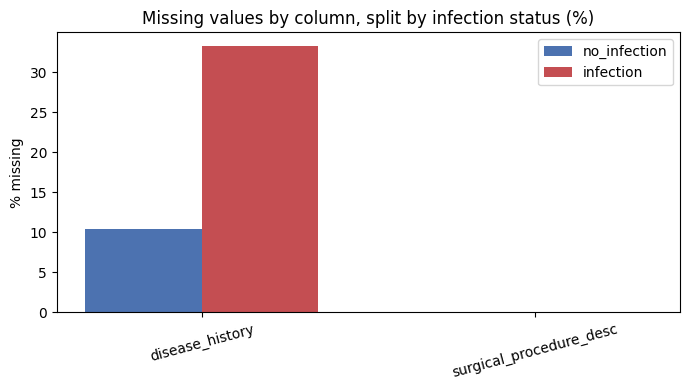

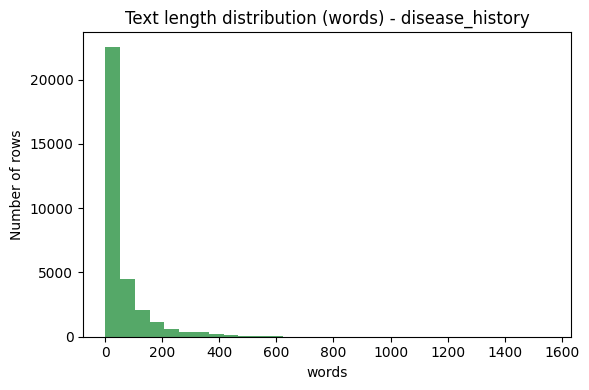

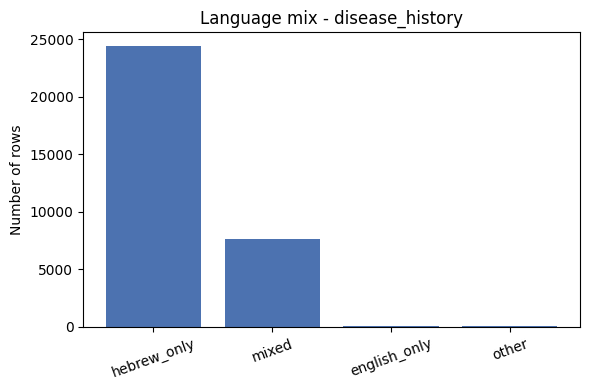

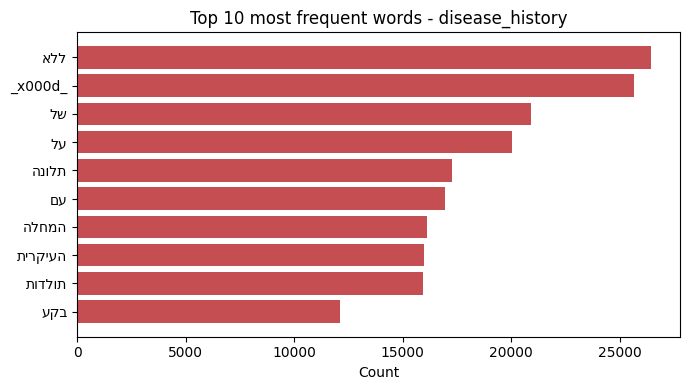

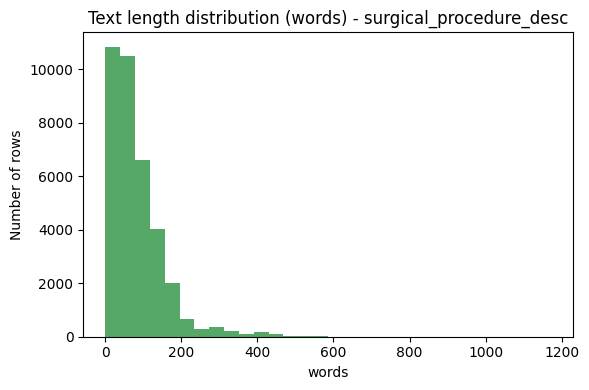

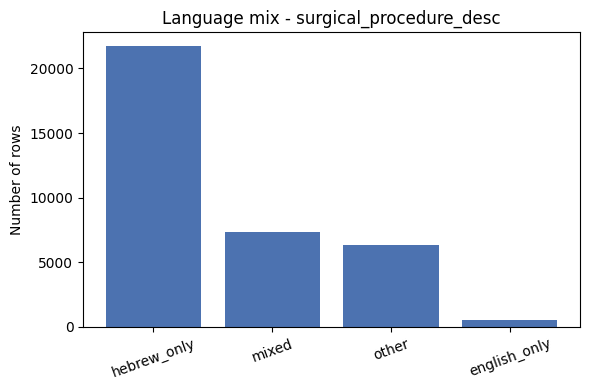

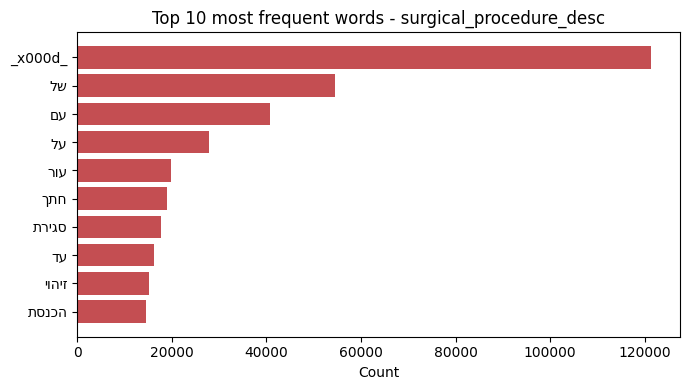

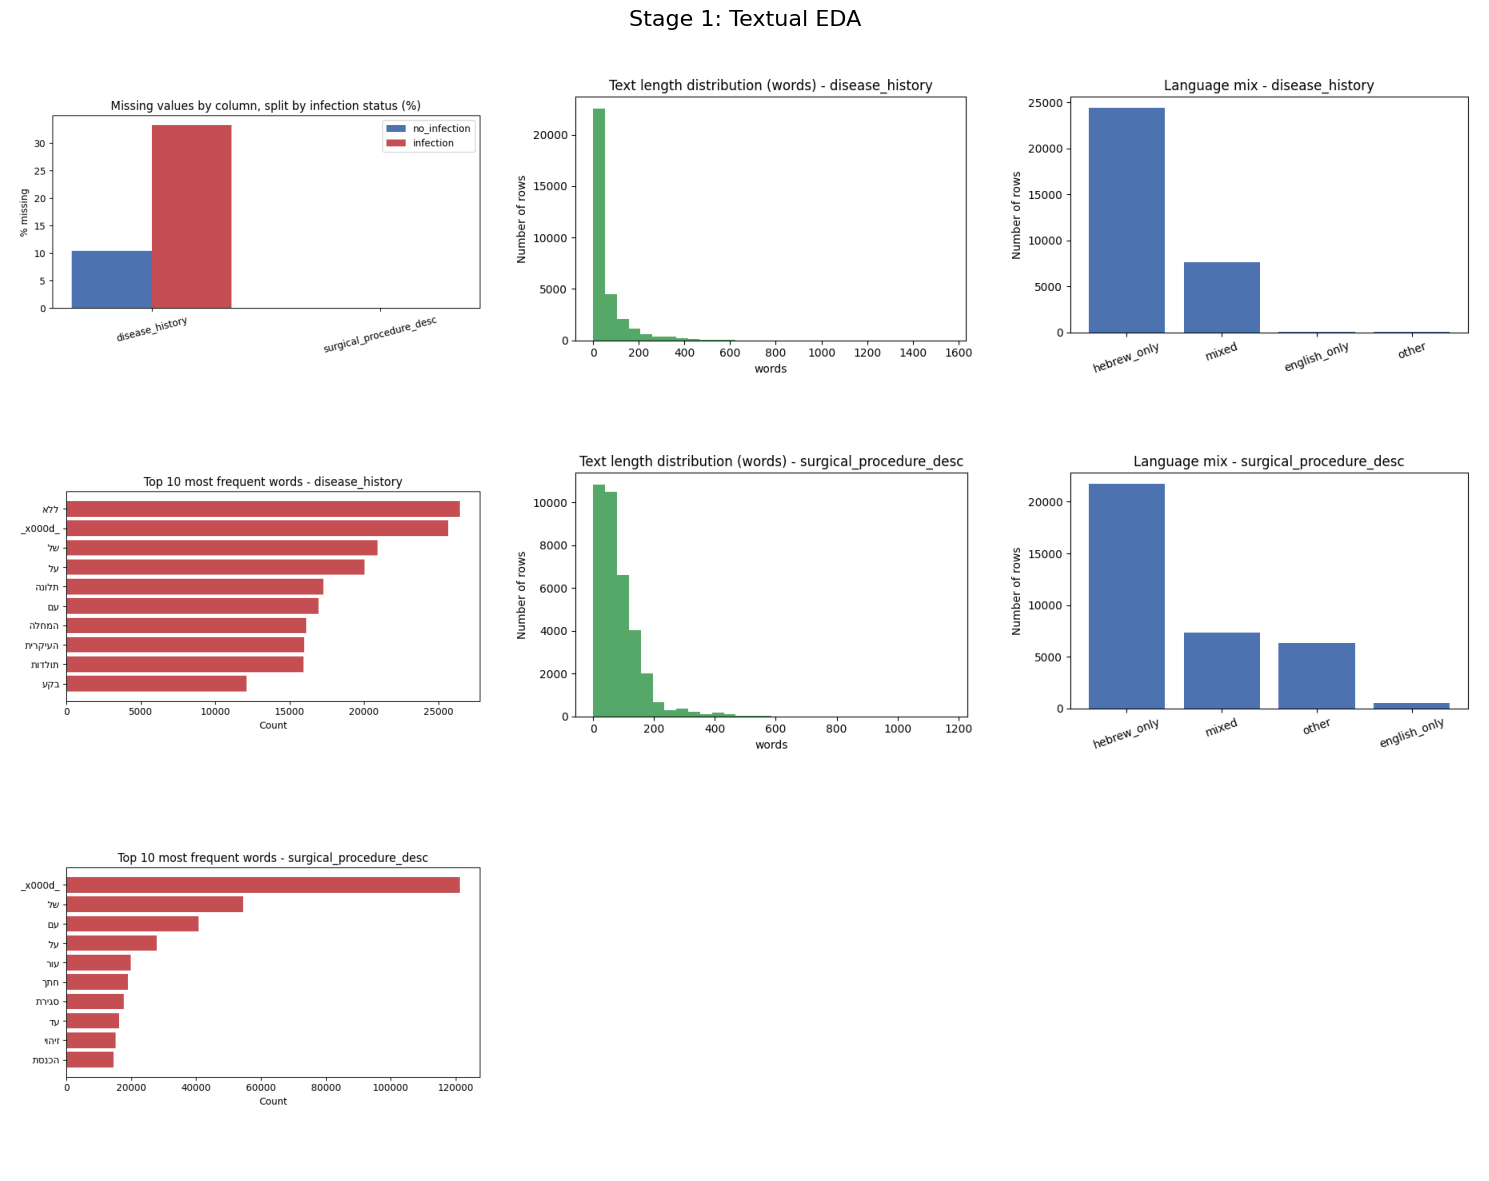


Overlap between 'main_complaint' and 'disease_history' (sample of 300 rows)
Average ratio: 0.30
Share of rows with high overlap (ratio > 0.6): 15.0%

main_complaint vs. disease_history overlap: 15.0% -> INCLUDE_MAIN_COMPLAINT_IN_PRIMARY_MODEL is currently on the exact same split (Section 13) if this comes back low and you want to test whether it adds independent signal.


In [ ]:
# ---- run Stage 1 ----
stage1_columns = list(TEXT_COLS)
with capture_figures() as figs:
    run_stage_1(df, text_columns=stage1_columns, label_col="infection") 
combine_figures(figs, title="Stage 1: Textual EDA", ncols=3, save_name="stage1_eda")


## Stage 2: Rule-based clinical Features Extraction and Dataset Preparation

Rule-based features are extracted from `disease_history`, where the structure and vocabulary of the note allow clinically interpretable information to be identified directly.

The extracted features include age-related information and predefined comorbidity such as diabetes, hypertension, cardiac disease and more...

The NLP dataset is then restricted to cases that remain in the final cleaned study cohort using `case_number`.

Separate dataset splits are also prepared for the baseline NLP model compraisons.

In [ ]:
SECTION_LABELS = [
    "תלונה העיקרית", "תולדות המחלה", "רקע", "רקע רפואי", "אבחנות",
    "טיפול תרופתי", "המלצות",
]
LABEL_SEP = "--"

AGE_RE = re.compile(r"\b(?:בת|בן)\s?(\d{1,3})\b")
DOB_RE = re.compile(r"\b(\d{1,2}/\d{1,2}/\d{4})\b")

COMORBIDITY_KEYWORDS = {
    "diabetes": ["סוכרת", "diabet"],
    "hypertension": ["יתר לחץ דם", "לחץ דם", "hypertension", "htn"],
    "ckd_renal": ["אי ספיקת כליות", "כליות", "renal failure", "ckd"],
    "cardiac_disease": ["מחלת לב", "אוטם", "cardiac", "coronary", "mi "],
    "respiratory_disease": ["קוצר נשימה", "copd", "אסטמה", "asthma", "ריאות"],
    "transplant": ["מושתל", "transplant"],
    "malignancy": ["גידול", "סרטן", "ממאיר", "cancer", "malignan"],
    "smoking": ["מעשן", "עישון", "smoking", "smoker"],
    "obesity": ["השמנה", "obesity", "bmi"],
    "immunosuppression": ["מדוכא חיסון", "immunosuppress", "סטרואידים"],
}


def split_labeled_sections(text):
    """Splits text into {label: content} based on SECTION_LABELS. Falls
    back to {'unlabeled': full_text} if no known label is found."""
    if not isinstance(text, str) or not text.strip():
        return {}
    pattern = "(" + "|".join(re.escape(lbl) for lbl in SECTION_LABELS) + ")"
    parts = re.split(pattern, text)
    if len(parts) == 1:
        return {"unlabeled": text.strip()}
    sections = {}
    leading = parts[0].strip()
    if leading:
        sections["unlabeled_prefix"] = leading
    i = 1
    while i < len(parts) - 1:
        label = parts[i].strip()
        content = parts[i + 1].strip()
        if content.startswith(LABEL_SEP):
            content = content[len(LABEL_SEP):].strip()
        sections[label] = content
        i += 2
    return sections


def extract_demographics(text):
    if not isinstance(text, str):
        return {"age": None, "dob": None}
    age_match = AGE_RE.search(text)
    dob_match = DOB_RE.search(text)
    return {
        "age": int(age_match.group(1)) if age_match else None,
        "dob": dob_match.group(1) if dob_match else None,
    }


def clean_clinical_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\u0590-\u05FF.%+-]", " ", text)
    return text.strip()


def extract_comorbidity_flags(text):
    text_lower = (text or "").lower()
    flags = {name: any(kw.lower() in text_lower for kw in kws) for name, kws in COMORBIDITY_KEYWORDS.items()}
    flags["comorbidity_count"] = sum(1 for v in flags.values() if v is True)
    return flags


def build_dictionary_features(df_input, column):
    rows = []
    for raw_text in df_input[column]:
        clean = clean_clinical_text(raw_text or "")
        demo = extract_demographics(raw_text or "")
        comorbid = extract_comorbidity_flags(clean)
        row = {"age_from_text": demo["age"], "dob_from_text": demo["dob"]}
        row.update(comorbid)
        rows.append(row)
    return pd.DataFrame(rows)


def stage2_feature_coverage(df_input, column):
    non_empty = df_input[column].dropna().astype(str)
    non_empty = non_empty[non_empty.str.strip() != ""]
    if len(non_empty) == 0:
        print(f"No non-empty values in '{column}'.")
        return pd.DataFrame(columns=["feature", "coverage_pct"])

    features = build_dictionary_features(pd.DataFrame({column: non_empty}), column)
    rows = [
        {"feature": "age_from_text", "coverage_pct": round(features["age_from_text"].notna().mean() * 100, 1)},
        {"feature": "dob_from_text", "coverage_pct": round(features["dob_from_text"].notna().mean() * 100, 1)},
    ]
    for flag in COMORBIDITY_KEYWORDS:
        rows.append({"feature": flag, "coverage_pct": round(features[flag].mean() * 100, 1)})

    report = pd.DataFrame(rows).sort_values("coverage_pct", ascending=False).reset_index(drop=True)
    print(f"Stage 2 feature coverage for '{column}' (n={len(non_empty)}):")
    print(report.to_string(index=False))
    return report


def make_shared_split_balanced_test(df_model, label_col="infection", test_pos_fraction=TEST_POS_FRACTION,
                                     test_neg_pos_ratio=TEST_NEG_POS_RATIO, random_state=RANDOM_STATE):
    """ONE train/test split shared across every model in this notebook -
    TEST is deliberately less imbalanced than raw prevalence; TRAIN keeps
    100% of the real data."""
    from sklearn.model_selection import train_test_split

    positive_idx = df_model.index[df_model[label_col] == 1]
    negative_idx = df_model.index[df_model[label_col] == 0]

    train_pos_idx, test_pos_idx = train_test_split(positive_idx, test_size=test_pos_fraction, random_state=random_state)

    n_test_neg = min(len(negative_idx), int(len(test_pos_idx) * test_neg_pos_ratio))
    test_neg_idx = negative_idx.to_series().sample(n=n_test_neg, random_state=random_state).index
    train_neg_idx = negative_idx.difference(test_neg_idx)

    df_train = df_model.loc[train_pos_idx.union(train_neg_idx)].copy()
    df_test = df_model.loc[test_pos_idx.union(test_neg_idx)].copy()
    return df_train, df_test


def subsample_full_dataset_negatives(df_model, n_negatives=OPTION_B_N_NEGATIVES, label_col="infection",
                                      random_state=RANDOM_STATE):
    """Option B: shrinks the negative class across the WHOLE dataset before
    any split - keeps every positive row plus a random sample of negatives."""
    positive_idx = df_model.index[df_model[label_col] == 1]
    negative_idx = df_model.index[df_model[label_col] == 0]
    n_negatives = min(n_negatives, len(negative_idx))
    kept_negative_idx = negative_idx.to_series().sample(n=n_negatives, random_state=random_state).index
    df_reduced = df_model.loc[positive_idx.union(kept_negative_idx)].copy()
    print(f"Option B pool: {len(df_reduced)} rows total "
          f"({len(positive_idx)} positive + {len(kept_negative_idx)} negative, "
          f"prevalence {len(positive_idx) / len(df_reduced):.2%})")
    return df_reduced


def make_shared_split_from_reduced_pool(df_reduced, label_col="infection", test_size=TEST_POS_FRACTION,
                                         random_state=RANDOM_STATE):
    from sklearn.model_selection import train_test_split

    train_idx, test_idx = train_test_split(df_reduced.index, test_size=test_size, random_state=random_state,
                                            stratify=df_reduced[label_col])
    df_train = df_reduced.loc[train_idx].copy()
    df_test = df_reduced.loc[test_idx].copy()
    return df_train, df_test


def print_split_report(df_train, df_test, label_col="infection"):
    for name, part in [("Train", df_train), ("Test", df_test)]:
        n = len(part)
        n_pos = int(part[label_col].sum())
        print(f"{name}: {n} rows, {n_pos} positive ({n_pos / n:.3%})")


def plot_split_balance(df_train, df_test, label_col="infection"):
    prevalence = {"Train": df_train[label_col].mean() * 100, "Test": df_test[label_col].mean() * 100}
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.bar(list(prevalence.keys()), list(prevalence.values()), color=["#4C72B0", "#C44E52"])
    ax.set_ylabel("Infection prevalence (%)")
    ax.set_title("Train vs. test infection prevalence")
    plt.tight_layout()
    plt.show()


In [ ]:
# ---- run Stage 2: dictionary features, then the shared split ----
print("### Stage 2: dictionary features ###")
stage2_feature_coverage(df, "disease_history")
dict_features = build_dictionary_features(df, "disease_history")
dict_features.index = df.index

DICT_FEATURE_COLS = ["age_from_text"] + list(COMORBIDITY_KEYWORDS.keys()) + ["comorbidity_count"]

model_text_cols = list(TEXT_COLS)

df_model = pd.concat([df[model_text_cols + ["infection"]], dict_features], axis=1)
if CASE_ID_COL:
    df_model[CASE_ID_COL] = df[CASE_ID_COL] if CASE_ID_COL in df.columns else df_zihum.loc[df.index, CASE_ID_COL]

#NEW: keep only cases remining after cleaning
nlp_df = df_model[df_model["case_number"].isin(final_cases)].copy()

print("NLP rows:", len(nlp_df))
print("Unique case numbers:", nlp_df["case_number"].nunique())
print("Duplicates:", nlp_df["case_number"].duplicated().sum())

print("\n### Stage 2b: shared train/test split - Option A ###")
df_train, df_test = make_shared_split_balanced_test(
    df_model, label_col="infection", test_pos_fraction=TEST_POS_FRACTION,
    test_neg_pos_ratio=TEST_NEG_POS_RATIO, random_state=RANDOM_STATE,
)
print_split_report(df_train, df_test)


### Stage 2: dictionary features ###
Stage 2 feature coverage for 'disease_history' (n=32165):
            feature  coverage_pct
      age_from_text          33.1
         malignancy          10.6
      dob_from_text           6.3
    cardiac_disease           5.1
       hypertension           4.8
            obesity           4.4
            smoking           2.8
respiratory_disease           2.7
           diabetes           1.6
          ckd_renal           0.6
  immunosuppression           0.5
         transplant           0.1
NLP rows: 31849
Unique case numbers: 31849
Duplicates: 0

### Stage 2b: shared train/test split - Option A ###
Train: 35606 rows, 112 positive (0.315%)
Test: 319 rows, 29 positive (9.091%)


## Shared evaluation utilities

The following functions provide a common evaluation framework for all NLP models

Each model is evaluated using the same set of classification metrics.

In [9]:
results = {}  # populated by compute_eval_metrics: results[model_name] = {...}


def compute_eval_metrics(y_test, y_pred, y_proba, model_name):
    """Registers the result under model_name in the module-level `results`
    dict for the final comparison stage. Reports PR-AUC/average_precision
    and test-set prevalence alongside ROC-AUC, since infection is a rare
    positive class and ROC-AUC alone can look deceptively good."""
    from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

    report = classification_report(y_test, y_pred, target_names=["no_infection", "infection"],
                                    zero_division=0, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    prevalence = np.mean(y_test)

    print(f"\n---- {model_name} ----")
    print(f"Test-set infection prevalence: {prevalence:.3%} ({int(np.sum(y_test))} of {len(y_test)})")
    print(f"ROC-AUC: {auc:.3f}")
    print(f"PR-AUC (average precision): {ap:.3f}")
    print(f"Precision/recall/F1 (infection class): "
          f"{report['infection']['precision']:.3f} / {report['infection']['recall']:.3f} / "
          f"{report['infection']['f1-score']:.3f}")

    results[model_name] = {
        "y_test": y_test, "y_pred": y_pred, "y_proba": y_proba,
        "roc_auc": auc, "average_precision": ap,
        "precision": report["infection"]["precision"],
        "recall": report["infection"]["recall"],
        "f1": report["infection"]["f1-score"],
    }
    return results[model_name]


def plot_confusion_matrix(y_test, y_pred, labels=("no_infection", "infection")):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion matrix (test set)")
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_test, y_proba):
    from sklearn.metrics import roc_curve, roc_auc_score

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})", color="#C44E52")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC curve (test set)")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_precision_recall_curve(y_test, y_proba):
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    baseline = np.mean(y_test)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})", color="#4C72B0")
    ax.axhline(baseline, linestyle="--", color="gray", label=f"No-skill baseline (prevalence = {baseline:.2%})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall curve (test set)")
    ax.legend()
    plt.tight_layout()
    plt.show()


## Stage 3: Baseline models - multi-column TF-IDF

Each of the two selected is processed using a separate `TfidfVectorizer` within a `ColumnTransformer`.

The fields are vectorized separatly because they represent different types of clinical documentation. Using an independent vocabulary for each field preserves fild-specific terminology and prevents the longer or more text source from dominaing the representation.

`max_features` is intentionally limited to 1,500 features per text field in order to control dimensionality and reduce the risk of overfitting, particularly given the strong class imbalance and the relatively small number fo potoperative infection cases.


In [ ]:
# Hebrew stopword list - sklearn/nltk don't ship one. Prefer stopwordsiso (pure word-list package)
HEBREW_STOPWORDS_FALLBACK = [
    "של", "עם", "על", "את", "לא", "כי", "גם", "אבל", "או", "זה", "זאת",
    "היה", "הייתה", "יש", "אין", "כן", "כדי", "בין", "אל", "מן", "כל",
]
try:
    import stopwordsiso
    HEBREW_STOPWORDS = sorted(stopwordsiso.stopwords("he"))
    print(f"Using stopwordsiso's Hebrew stopword list ({len(HEBREW_STOPWORDS)} words).")
except ImportError:
    HEBREW_STOPWORDS = HEBREW_STOPWORDS_FALLBACK
    print(f"stopwordsiso not installed - using the manual {len(HEBREW_STOPWORDS_FALLBACK)}-word fallback list.")


def build_multitext_tfidf_pipeline(text_cols, max_features_per_field=1500, ngram_range=(1, 2), C=1.0):
    """Pipeline: one TfidfVectorizer per text column (ColumnTransformer) ->
    LogisticRegression. max_features is deliberately modest per field,
    given how few positive examples exist in total."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline

    transformers = [
        (f"tfidf_{col}", TfidfVectorizer(max_features=max_features_per_field, ngram_range=ngram_range,
                                           stop_words=HEBREW_STOPWORDS, min_df=2), col)
        for col in text_cols
    ]
    column_transformer = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=1.0)
    classifier = LogisticRegression(max_iter=1000, C=C, class_weight="balanced")
    return Pipeline([("tfidf", column_transformer), ("clf", classifier)])


def get_top_features_multitext(pipeline, top_n=20):
    """Same idea as the single-column version, but labels each word with
    the field it came from (e.g. 'disease_history::סוכרת'), since the same
    word can appear in more than one field's vocabulary."""
    column_transformer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    coefs = clf.coef_[0]

    feature_names = []
    for name, vectorizer, col in column_transformer.transformers_:
        if name == "remainder":
            continue
        for word in vectorizer.get_feature_names_out():
            feature_names.append(f"{col}::{word}")

    order = np.argsort(coefs)
    top_negative = [(feature_names[i], coefs[i]) for i in order[:top_n]]
    top_positive = [(feature_names[i], coefs[i]) for i in order[-top_n:][::-1]]
    return {"top_positive_(higher_risk)": top_positive, "top_negative_(lower_risk)": top_negative}


def evaluate_multitext_tfidf_model_on_split(df_train, df_test, text_cols, label_col, **pipeline_kwargs):
    from sklearn.metrics import classification_report

    X_train = df_train[text_cols].fillna("").astype(str)
    X_test = df_test[text_cols].fillna("").astype(str)
    y_train = df_train[label_col]
    y_test = df_test[label_col]

    pipeline = build_multitext_tfidf_pipeline(text_cols, **pipeline_kwargs)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    print("\nClassification report (on shared TEST split, not seen during training):")
    print(classification_report(y_test, y_pred, target_names=["no_infection", "infection"], zero_division=0))

    return {"pipeline": pipeline, "X_test": X_test, "y_test": y_test, "y_pred": y_pred, "y_proba": y_proba}


def plot_top_tfidf_features_multitext(pipeline, top_n=15):
    top = get_top_features_multitext(pipeline, top_n=top_n)
    words = [w for w, _ in top["top_positive_(higher_risk)"]] + [w for w, _ in top["top_negative_(lower_risk)"]]
    coefs = [c for _, c in top["top_positive_(higher_risk)"]] + [c for _, c in top["top_negative_(lower_risk)"]]

    order = sorted(range(len(coefs)), key=lambda i: coefs[i])
    labels = [_hebrew_display(words[i]) for i in order]
    values = [coefs[i] for i in order]
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in values]

    fig, ax = plt.subplots(figsize=(8, max(4, len(labels) * 0.3)))
    ax.barh(labels, values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Words associated with higher risk (red) vs. lower risk (blue), by field")
    ax.set_xlabel("Logistic regression coefficient")
    plt.tight_layout()
    plt.show()


Using stopwordsiso's Hebrew stopword list (194 words).


### TF-IDF + Logitic regression

### Stage 3: TF-IDF (per-field) + Logistic Regression (shared split) ###
Train size: 35606, Test size: 319

Classification report (on shared TEST split, not seen during training):
              precision    recall  f1-score   support

no_infection       0.95      0.96      0.96       290
   infection       0.58      0.52      0.55        29

    accuracy                           0.92       319
   macro avg       0.76      0.74      0.75       319
weighted avg       0.92      0.92      0.92       319


---- TF-IDF + LogisticRegression ----
Test-set infection prevalence: 9.091% (29 of 319)
ROC-AUC: 0.933
PR-AUC (average precision): 0.519
Precision/recall/F1 (infection class): 0.577 / 0.517 / 0.545
Words associated with higher risk: [('disease_history::for', np.float64(6.479905696039562)), ('surgical_procedure_desc::קצה ממארי', np.float64(4.455565797795345)), ('surgical_procedure_desc::המעי', np.float64(4.307889267220229)), ('surgical_procedure_desc::זוגות', np.float64(4.174927124332133)

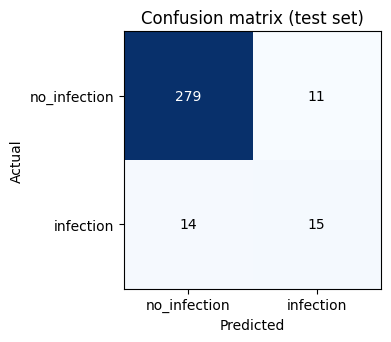

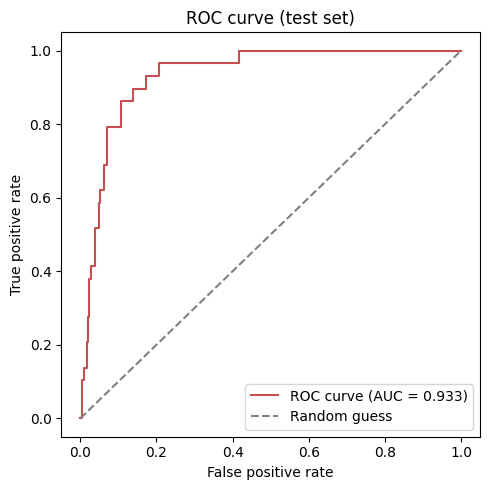

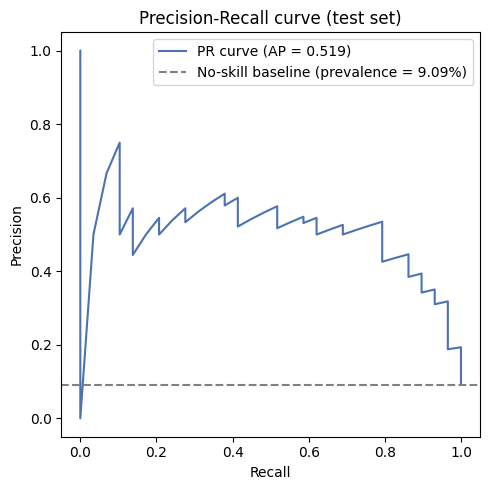

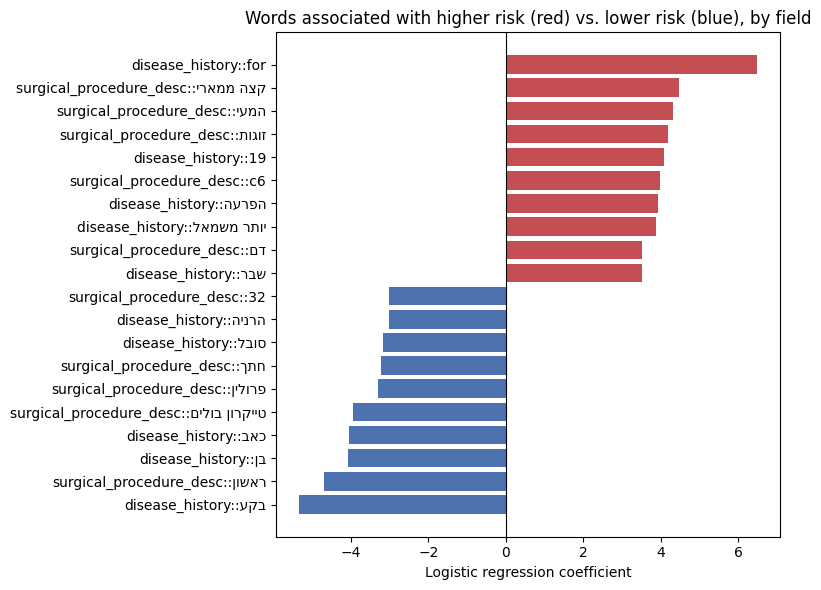

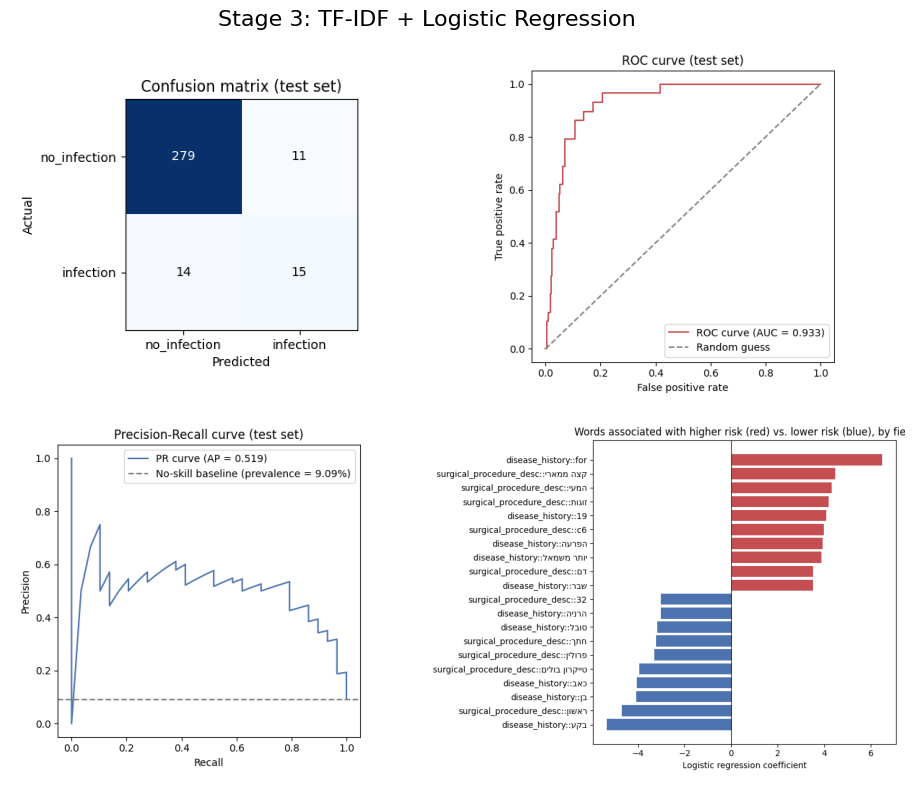

In [ ]:
print("### Stage 3: TF-IDF (per-field) + Logistic Regression (shared split) ###")
tfidf_eval = evaluate_multitext_tfidf_model_on_split(
    df_train, df_test, text_cols=model_text_cols, label_col="infection",
    max_features_per_field=1500, ngram_range=(1, 2),
)
compute_eval_metrics(tfidf_eval["y_test"], tfidf_eval["y_pred"], tfidf_eval["y_proba"],
                      model_name="TF-IDF + LogisticRegression")

top = get_top_features_multitext(tfidf_eval["pipeline"], top_n=5)
print("Words associated with higher risk:", top["top_positive_(higher_risk)"])
print("Words associated with lower risk :", top["top_negative_(lower_risk)"])

with capture_figures() as figs:
    plot_confusion_matrix(tfidf_eval["y_test"], tfidf_eval["y_pred"])
    plot_roc_curve(tfidf_eval["y_test"], tfidf_eval["y_proba"])
    plot_precision_recall_curve(tfidf_eval["y_test"], tfidf_eval["y_proba"])
    plot_top_tfidf_features_multitext(tfidf_eval["pipeline"], top_n=10)
combine_figures(figs, title="Stage 3: TF-IDF + Logistic Regression", save_name="stage3_tfidf_logreg")


### TF-IDF + XGBoost

Same per-field TF-IDF representation as Stage 3, trained with XGBoost instead of Logistic Regression, evaluated on the same shared test split.

Class imbalance is addressed using `scale_pos_weight, calculated from the training data.


In [12]:
def build_multitext_tfidf_features(df_train, df_test, text_cols, max_features_per_field=1500, ngram_range=(1, 2)):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.compose import ColumnTransformer

    transformers = [
        (f"tfidf_{col}", TfidfVectorizer(max_features=max_features_per_field, ngram_range=ngram_range,
                                           stop_words=HEBREW_STOPWORDS, min_df=2), col)
        for col in text_cols
    ]
    column_transformer = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=1.0)
    X_train = column_transformer.fit_transform(df_train[text_cols].fillna("").astype(str))
    X_test = column_transformer.transform(df_test[text_cols].fillna("").astype(str))
    return X_train, X_test


def train_xgb_on_embeddings(X_train, y_train, X_test, use_smote=False, random_state=RANDOM_STATE):
    """Trains XGBoost on a feature matrix - handles the extreme class
    imbalance via scale_pos_weight (default) or SMOTE oversampling of the
    TRAINING set only."""
    from xgboost import XGBClassifier

    if use_smote:
        from imblearn.over_sampling import SMOTE
        sm = SMOTE(random_state=random_state)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        model = XGBClassifier(eval_metric="logloss", random_state=random_state)
    else:
        n_pos = int(np.sum(y_train))
        n_neg = int(len(y_train) - n_pos)
        scale_pos_weight = n_neg / max(n_pos, 1)
        model = XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=random_state)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return model, y_pred, y_proba


### Stage 3b: TF-IDF (per-field) + XGBoost (shared split) ###

---- TF-IDF + XGBoost ----
Test-set infection prevalence: 9.091% (29 of 319)
ROC-AUC: 0.821
PR-AUC (average precision): 0.304
Precision/recall/F1 (infection class): 0.286 / 0.069 / 0.111
Saved to H:/27 project/models/NLP_visualization\stage3b_tfidf_xgboost.png


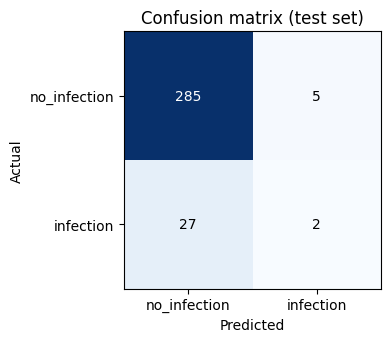

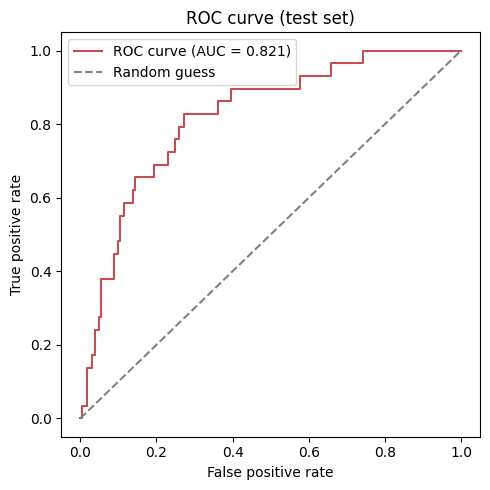

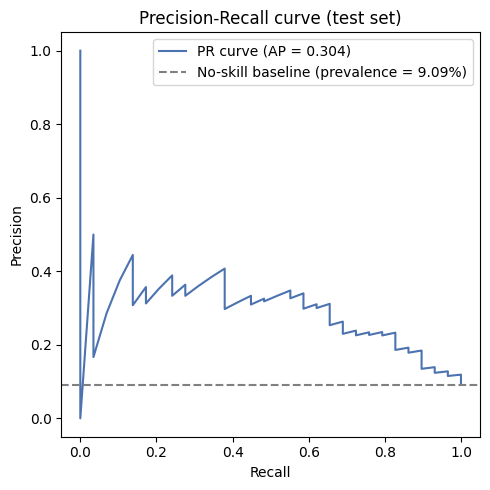

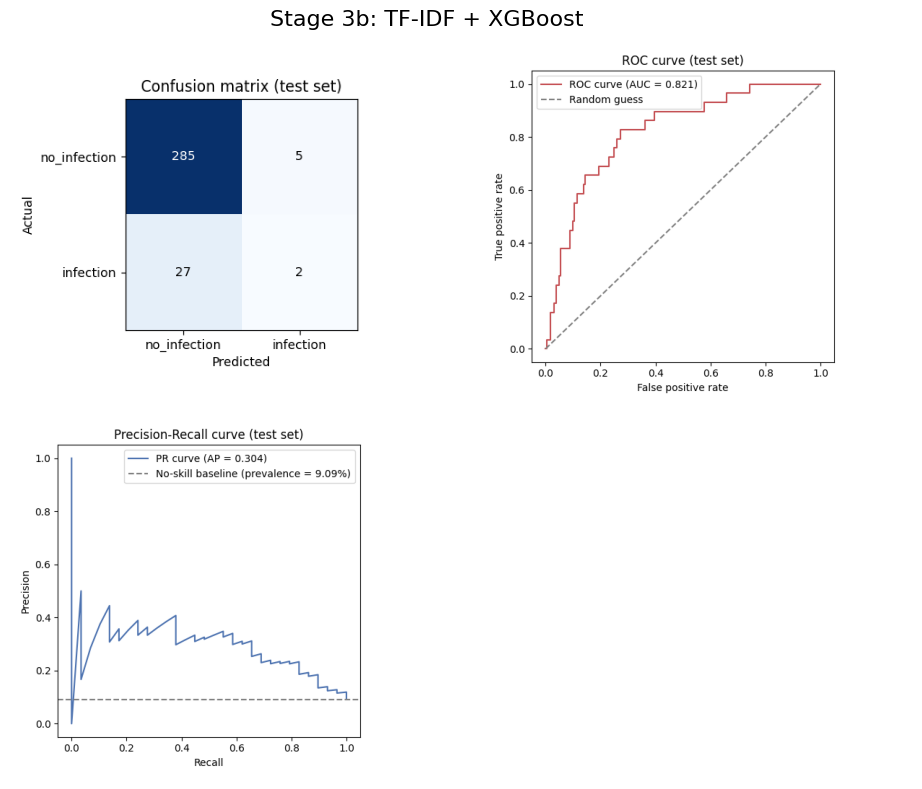

In [ ]:
print("### Stage 3b: TF-IDF (per-field) + XGBoost (shared split) ###")
X_train_tfidf, X_test_tfidf = build_multitext_tfidf_features(df_train, df_test, text_cols=model_text_cols,
                                                               max_features_per_field=1500, ngram_range=(1, 2))
y_train_tfidf = df_train["infection"]
y_test_tfidf = df_test["infection"]

_, y_pred_tfidf_xgb, y_proba_tfidf_xgb = train_xgb_on_embeddings(X_train_tfidf, y_train_tfidf, X_test_tfidf)
compute_eval_metrics(y_test_tfidf, y_pred_tfidf_xgb, y_proba_tfidf_xgb, model_name="TF-IDF + XGBoost")

with capture_figures() as figs:
    plot_confusion_matrix(y_test_tfidf, y_pred_tfidf_xgb)
    plot_roc_curve(y_test_tfidf, y_proba_tfidf_xgb)
    plot_precision_recall_curve(y_test_tfidf, y_proba_tfidf_xgb)
combine_figures(figs, title="Stage 3b: TF-IDF + XGBoost", save_name="stage3b_tfidf_xgboost")


## Stage 4: Local Llama Inference

A locally hosted Llamamodel  is used to analyze the text fields together for each surgical case.

Each field is presented separatly within a structure prompt so that the model retains information about the source note.

The model is instructed to estimate infection risk using only information contained in the supplied clinical text and to return a structured JSON response.

The output includes:
- a continuous `risk_score`
- a binary risk class
- structured indicators for infection-related concerns
- a short textual explanation

Inference is performed through the hospital's local Ollana endpoint with deterministic temperature settings.

Every response is cached to `LLAMA_CACHE_PATH` and are validated and standartized before being stored.

In [ ]:
# The prompt is written to ask for risk factors / early warning signs, deliberately distinct from 
# "does this text already describe a confirmed infection" - the two are easy to conflate, and conflating them 
# would defeat the point of an early-prediction model. A model that only recognizes infections already 
# documented in the text is not predicting anything - it is reading the answer off the page.
LLAMA_SYSTEM_PROMPT = """
You are analyzing de-identified clinical text from postoperative surgical admissions, as part
of an EARLY-WARNING risk model - not a diagnostic tool.

Task:
Estimate the RISK that this patient will develop a postoperative infection, based only on risk
factors and early warning signs present in the text (e.g. comorbidities, wound-care details,
early systemic signs, antibiotic/culture orders). This is a forward-looking risk estimate, not
a confirmation of a current or already-documented infection - do not simply search for the word
"infection" or an existing diagnosis and report that as the risk. A patient can be high-risk with
no infection mentioned yet, and a text can mention "SSI" as part of a differential/history
without that being the correct signal to key off of.

Important constraints:
- Use only the text supplied in this prompt.
- Do not invent facts.
- Do not assume a confirmed infection diagnosis unless it is explicitly and unambiguously stated.
- The notes may be in Hebrew, English, or mixed Hebrew/English.
- Return valid JSON only, no extra commentary.

Required JSON schema:
{
  "risk_score": number from 0.0 to 1.0 (your own estimate of infection risk - NOT a
      calibrated statistical probability, just your best judgment on this scale),
  "risk_class": "low" or "high",
  "infection_concern_mentioned": 0 or 1,
  "wound_problem_mentioned": 0 or 1,
  "fever_or_systemic_sign_mentioned": 0 or 1,
  "antibiotic_or_culture_mentioned": 0 or 1,
  "major_comorbidity_mentioned": 0 or 1,
  "postoperative_complication_mentioned": 0 or 1,
  "reason_short": "short explanation, maximum 25 words"
}
""".strip()

LLAMA_NUMERIC_FEATURES = [
    "risk_score",
    "infection_concern_mentioned",
    "wound_problem_mentioned",
    "fever_or_systemic_sign_mentioned",
    "antibiotic_or_culture_mentioned",
    "major_comorbidity_mentioned",
    "postoperative_complication_mentioned",
]


def build_llama_user_prompt(row, text_cols=TEXT_COLS):
    """Sends all 3 fields together, each explicitly labeled, rather than a
    single blended string - the model can see which statement came from
    which note type."""
    fields = []
    for col in text_cols:
        value = row.get(col, "")
        if pd.isna(value):
            value = ""
        fields.append(f"### {col}\n{str(value).strip()}")
    return "Analyze the following clinical text fields.\n\n" + "\n\n".join(fields)


def _ollama_http_chat(system_prompt, user_prompt):
    payload = {
        "model": LLAMA_MODEL_NAME,
        "stream": False,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "options": {"temperature": 0},
    }
    import requests
    r = requests.post(LLAMA_OLLAMA_URL, json=payload, timeout=LLAMA_TIMEOUT_SECONDS)
    r.raise_for_status()
    return r.json()["message"]["content"]


def local_llama_chat(system_prompt, user_prompt):
    if LLAMA_MODEL_NAME.startswith("TODO_"):
        raise ValueError("LLAMA_MODEL_NAME is still a placeholder - ask IT for the exact "
                          "local model identifier before running inference.")
    if LLAMA_BACKEND == "ollama_http":
        return _ollama_http_chat(system_prompt, user_prompt)
    raise ValueError(f"Unsupported LLAMA_BACKEND: {LLAMA_BACKEND}")


def extract_json_object(text):
    """Parses a JSON object even if the model wraps it in markdown fences
    or adds a short prefix/suffix around it."""
    if not isinstance(text, str):
        raise ValueError("Llama response is not text.")
    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:json)?", "", cleaned, flags=re.I).strip()
    cleaned = re.sub(r"```$", "", cleaned).strip()
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", cleaned, flags=re.S)
        if not match:
            raise
        return json.loads(match.group(0))


def normalize_llama_output(parsed):
    """
    INFO:
    Clamps/validates the parsed JSON into a predictable shape - never raises on a slightly malformed field, 
    so one odd reply doesn't abort the whole evaluation loop. If risk_score is missing/unparsable, it
    comes out as NaN here (not a guessed default) - the caller below treats a NaN risk_score as a failed row,
    excluded from evaluation and counted in the reported failure rate, never silently treated as 'no_infection'.

    IMPORTANT: risk_score is the model's own self-reported 0-1 estimate, not a calibrated statistical probability -
    do not describe it as "probability of infection" in the report; call it a risk score.
    """
    out = {}
    try:
        score = float(parsed.get("risk_score", np.nan))
    except (TypeError, ValueError):
        score = np.nan
    out["risk_score"] = min(max(score, 0.0), 1.0) if np.isfinite(score) else np.nan

    risk_class = str(parsed.get("risk_class", "")).strip().lower()
    out["risk_class"] = risk_class if risk_class in {"low", "high"} else ""

    for col in LLAMA_NUMERIC_FEATURES[1:]:
        try:
            out[col] = int(float(parsed.get(col, 0)) > 0)
        except (TypeError, ValueError):
            out[col] = 0

    out["reason_short"] = str(parsed.get("reason_short", "")).strip()
    return out


In [ ]:
# ---- cache / resume ----

def load_llama_cache(path=LLAMA_CACHE_PATH):
    path = Path(path)
    if path.exists():
        cache = pd.read_csv(path)
        if "_row_key" in cache.columns:
            cache["_row_key"] = cache["_row_key"].astype(str)
        return cache
    return pd.DataFrame()


def save_llama_cache(cache_df, path=LLAMA_CACHE_PATH):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cache_df.to_csv(path, index=False, encoding="utf-8-sig")


def row_key_from_index(index_value, row):
    if CASE_ID_COL and CASE_ID_COL in row.index and pd.notna(row[CASE_ID_COL]):
        return str(row[CASE_ID_COL])
    return str(index_value)


def run_llama_inference(df_input, max_rows=LLAMA_MAX_ROWS, checkpoint_every=LLAMA_CHECKPOINT_EVERY,
                         text_cols=TEXT_COLS):
    """Resumable, inference-only classification: skips rows already present
    in the on-disk cache, checkpoints new results every `checkpoint_every`
    rows, and keeps going even when individual calls fail (recorded in
    llama_error instead of raising).

    A row counts as a FAILURE - and gets risk_score=NaN, never a guessed
    label - both when the API call/JSON-parse raises an exception AND when
    it succeeds but comes back without a usable risk_score (e.g. valid
    JSON missing that key). Either way the row is excluded from evaluation
    later (see attach_llama_to_dataframe + the notna() filter in Stage 4's
    evaluation cell) rather than silently defaulted to "no_infection"."""
    cache = load_llama_cache()
    completed = set(cache["_row_key"].astype(str)) if not cache.empty else set()

    work = df_input.copy()
    if max_rows is not None:
        work = work.head(max_rows)

    new_rows = []
    n_failures = 0

    for counter, (idx, row) in enumerate(work.iterrows(), start=1):
        key = row_key_from_index(idx, row)
        if key in completed:
            continue

        user_prompt = build_llama_user_prompt(row, text_cols=text_cols)
        raw_response, parsed_output, error_text = None, None, ""

        for attempt in range(1, LLAMA_MAX_RETRIES + 2):
            try:
                raw_response = local_llama_chat(LLAMA_SYSTEM_PROMPT, user_prompt)
                parsed = extract_json_object(raw_response)
                parsed_output = normalize_llama_output(parsed)
                break
            except Exception as exc:
                error_text = f"{type(exc).__name__}: {exc}"
                if attempt <= LLAMA_MAX_RETRIES:
                    time.sleep(2 * attempt)

        # A row is a "failure" for reporting purposes whenever it ends up without a usable risk_score -
        #  whether the whole call raised, or it returned valid-but-incomplete JSON (parsed_output not None but
        # its risk_score is NaN). Checked explicitly rather than only trusting "parsed_output is None", 
        # so the printed failure rate matches exactly what evaluation ends up excluding.
        row_failed = parsed_output is None or not np.isfinite(parsed_output.get("risk_score", np.nan))
        if row_failed:
            n_failures += 1
            if not error_text:
                error_text = "no risk_score in parsed response"

        record = {
            "_row_key": key,
            "_original_index": idx,
            "llama_error": error_text if row_failed else "",
            "llama_raw_response": raw_response if raw_response is not None else "",
        }
        if parsed_output is not None:
            record.update(parsed_output)
        else:
            for col in LLAMA_NUMERIC_FEATURES:
                record[col] = np.nan
            record["risk_class"] = ""
            record["reason_short"] = ""

        new_rows.append(record)
        completed.add(key)

        if len(new_rows) >= checkpoint_every:
            cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
            save_llama_cache(cache)
            new_rows = []
            print(f"  ...checkpoint saved after {counter}/{len(work)} rows "
                  f"({n_failures} failures so far)")

    if new_rows:
        cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
        save_llama_cache(cache)

    failure_rate = n_failures / len(work) if len(work) else float("nan")
    print(f"Finished this call: {len(work)} rows requested, {n_failures} failures "
          f"({failure_rate:.1%}) - failed rows are cached with risk_score=NaN and "
          f"excluded from evaluation, not defaulted to no_infection.")
    return cache


def attach_llama_to_dataframe(df_input, llama_cache):
    work = df_input.copy()
    work["_row_key"] = [row_key_from_index(idx, row) for idx, row in work.iterrows()]
    llama_cache = llama_cache.copy()
    if not llama_cache.empty:
        llama_cache["_row_key"] = llama_cache["_row_key"].astype(str)
    work["_row_key"] = work["_row_key"].astype(str)
    return work.merge(llama_cache, on="_row_key", how="left", suffixes=("", "_llama"))


In [ ]:
# smoke test 
smoke_cache = run_llama_inference(nlp_df.head(20), max_rows=None)
print(smoke_cache[["_row_key", "risk_score", "risk_class", "llama_error"]].tail(20))

Finished this call: 20 rows requested, 0 failures (0.0%) - failed rows are cached with risk_score=NaN and excluded from evaluation, not defaulted to no_infection.
    _row_key  risk_score risk_class llama_error
0   20737308         0.4        low         NaN
1   20737323         0.2        low         NaN
2   20737310         0.4        low         NaN
3   20737307         0.2        low         NaN
4   20737317         0.4        low         NaN
5   20737354         0.2        low            
6   20737309         0.4        low            
7   20737244         0.4        low            
8   20737385         0.4        low            
9   20737377         0.2        low            
10  20737392         0.2        low            
11  20737386         0.6       high            
12  20737305         0.6       high            
13  20737390         0.2        low            
14  20737391         0.6       high            
15  20737376         0.4        low            
16  20737400         

In [ ]:
#full llama run in batches
BATCH_SIZE = 500

for start in range(0, len(nlp_df), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(nlp_df))
    batch = nlp_df.iloc[start:end]

    print(f"\nRunning rows {start} to {end - 1}...")

    run_llama_inference(batch, max_rows=None)

# NOTE: rows where risk_score is NaN are failures (JSON/API error, or a reply missing risk_score) - 
# they are dropped here, NOT counted as no_infection. This is deliberate: silently defaulting a failed call to
# "no_infection" would quietly bias every metric below toward looking better than the model actually performed.


Running rows 0 to 499...
  ...checkpoint saved after 45/500 rows (0 failures so far)
  ...checkpoint saved after 70/500 rows (0 failures so far)
  ...checkpoint saved after 95/500 rows (0 failures so far)
  ...checkpoint saved after 120/500 rows (0 failures so far)
  ...checkpoint saved after 145/500 rows (0 failures so far)
  ...checkpoint saved after 170/500 rows (0 failures so far)
  ...checkpoint saved after 195/500 rows (0 failures so far)
  ...checkpoint saved after 220/500 rows (0 failures so far)
  ...checkpoint saved after 245/500 rows (0 failures so far)
  ...checkpoint saved after 270/500 rows (0 failures so far)
  ...checkpoint saved after 295/500 rows (0 failures so far)
  ...checkpoint saved after 320/500 rows (0 failures so far)
  ...checkpoint saved after 345/500 rows (0 failures so far)
  ...checkpoint saved after 370/500 rows (0 failures so far)
  ...checkpoint saved after 395/500 rows (0 failures so far)
  ...checkpoint saved after 420/500 rows (0 failures so far)
 

  ...checkpoint saved after 198/319 rows (0 failures so far)
Finished this call: 319 rows requested, 0 failures (0.0%) - failed rows are cached with risk_score=NaN and excluded from evaluation, not defaulted to no_infection.
Llama evaluation: 319 usable rows, 0 excluded due to parse/call failures (0.0% of the test split).

---- Llama (llama3.3:70b, prompted) ----
Test-set infection prevalence: 9.091% (29 of 319)
ROC-AUC: 0.701
PR-AUC (average precision): 0.183
Precision/recall/F1 (infection class): 0.169 / 0.345 / 0.227
Saved to H:/27 project/models/NLP_visualization\stage4_llama.png


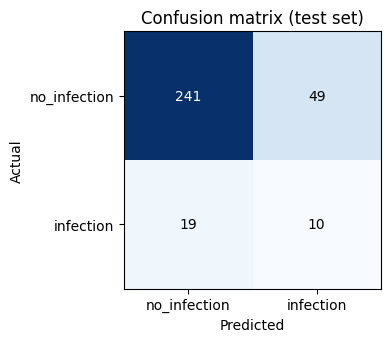

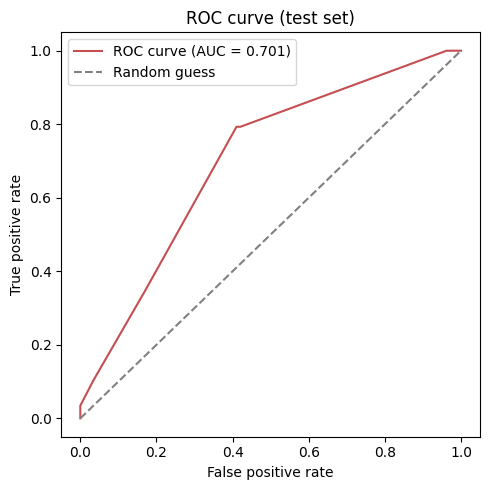

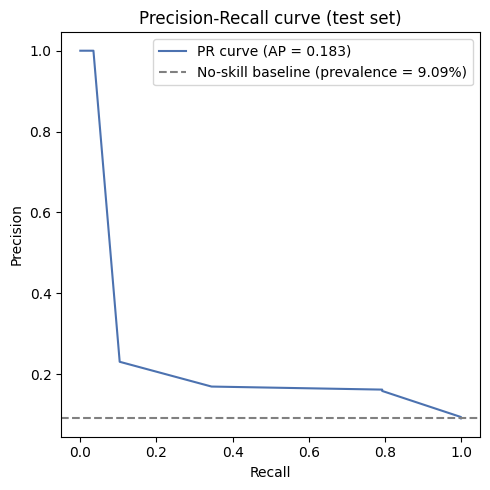

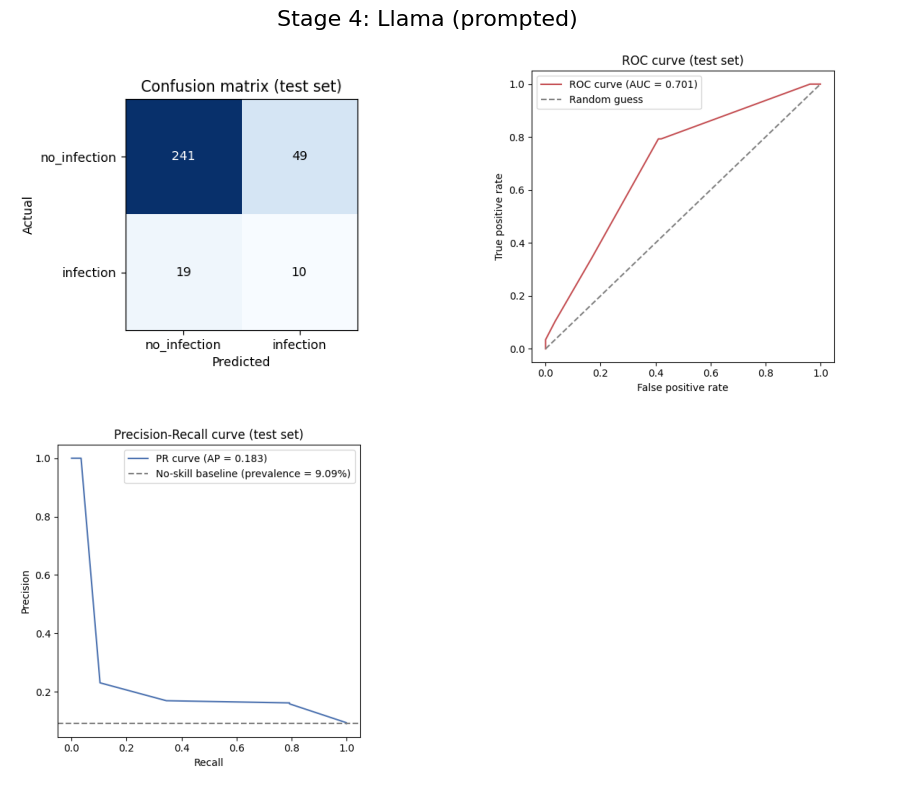

Stage 4 is commented out on purpose - fill in LLAMA_MODEL_NAME (and the endpoint, if needed) at the top of the notebook, then uncomment the block above.


In [17]:
#Load the already-generated llama results from the cache and attach them to the test set
llama_scope_df = df_test if LLAMA_RUN_SCOPE == "test_only" else df_model
llama_cache = run_llama_inference(llama_scope_df, max_rows=None)
test_with_llama = attach_llama_to_dataframe(df_test, llama_cache)

#Keep only rows with a valid llama risk score
valid = test_with_llama["risk_score"].notna()
n_excluded = (~valid).sum()
print(f"Llama evaluation: {valid.sum()} usable rows, {n_excluded} excluded "
      f"due to parse/call failures ({n_excluded / len(test_with_llama):.1%} of the test split).")

#True labels and llama predictions
y_test_llama = test_with_llama.loc[valid, "infection"].astype(int).values
y_score_llama = test_with_llama.loc[valid, "risk_score"].astype(float).values  # model's own
# risk estimate - NOT a calibrated probability, just fed into y_proba-shaped
# metric functions (ROC/PR-AUC) the same way every other model's score is
y_pred_llama = (y_score_llama >= 0.5).astype(int)

#Metrics
llama_model_name = f"Llama ({LLAMA_MODEL_NAME}, prompted)"
compute_eval_metrics(y_test_llama, y_pred_llama, y_score_llama, model_name=llama_model_name)

#Evaluatiions plots
with capture_figures() as figs:
    plot_confusion_matrix(y_test_llama, y_pred_llama)
    plot_roc_curve(y_test_llama, y_score_llama)
    plot_precision_recall_curve(y_test_llama, y_score_llama)
combine_figures(figs, title="Stage 4: Llama (prompted)", save_name="stage4_llama")

print("Stage 4 is commented out on purpose - fill in LLAMA_MODEL_NAME (and the endpoint, "
      "if needed) at the top of the notebook, then uncomment the block above.")

## Stage 4b: export Llama-derived features for the tabular model

The cached Llama outputs are merged back to the case-level dataset and exported as a seperate feature table.

The exported table contains the case identifier together with the structured numeric outputs generated by Llama and the predicted risk class.

Llama feature names are prefixed with `nlp_llama__` so that they can be clearly distinguished when merged into the structured modeling dataset/

In [ ]:
def export_llama_features(source_df, llama_cache, output_path=LLAMA_FEATURES_PATH):
    merged = attach_llama_to_dataframe(source_df, llama_cache)

    id_col = CASE_ID_COL if CASE_ID_COL and CASE_ID_COL in merged.columns else "_row_key"
    feature_cols = [id_col] + LLAMA_NUMERIC_FEATURES + ["risk_class"]

    out = merged[feature_cols].copy()
    rename_map = {col: f"nlp_llama__{col}" for col in LLAMA_NUMERIC_FEATURES + ["risk_class"]}
    out = out.rename(columns=rename_map)

    out.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved Llama feature table to: {output_path} ({len(out)} rows)")
    return out


# Using only after running Llama with LLAMA_RUN_SCOPE = "all":
llama_cache = load_llama_cache()
llama_features = export_llama_features(df_model, llama_cache)


Saved Llama feature table to: H:/27 project/models/llama_features.csv (35925 rows)


## Stage 5: Model comparison

The evaluated NLP models are compared using the metrics stored in the shared `resukts` registry.

The comparison table reports ROC-AUC, PR-AUC, precision, recall and F1-score for the infection class.
Precision-Recall curves are plotted together because PR-AUC is particularly informative for the highly imbalancel infection outcome.


In [ ]:
def build_comparison_table(results_dict, model_order):
    rows = []
    for name in model_order:
        r = results_dict[name]
        rows.append({
            "model": name,
            "roc_auc": round(r["roc_auc"], 3),
            "pr_auc": round(r["average_precision"], 3),
            "precision_infection": round(r["precision"], 3),
            "recall_infection": round(r["recall"], 3),
            "f1_infection": round(r["f1"], 3),
        })
    return pd.DataFrame(rows)


def plot_combined_pr_curves(results_dict, model_order):
    from sklearn.metrics import precision_recall_curve

    fig, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(model_order)))
    for name, color in zip(model_order, colors):
        r = results_dict[name]
        precision, recall, _ = precision_recall_curve(r["y_test"], r["y_proba"])
        ax.plot(recall, precision, label=f"{name} (AP={r['average_precision']:.3f})", color=color)

    baseline = np.mean(results_dict[model_order[0]]["y_test"])
    ax.axhline(baseline, linestyle="--", color="gray", label=f"No-skill baseline ({baseline:.3%})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall curves - all models (shared test set)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# ---- run Stage 5 ----
print("### Stage 5: Model comparison (all evaluated on the SAME shared test set) ###")
model_order = ["TF-IDF + LogisticRegression", "TF-IDF + XGBoost"]
llama_model_name = f"Llama ({LLAMA_MODEL_NAME}, prompted)"
if llama_model_name in results:
    model_order.append(llama_model_name)
else:
    print(f"Note: '{llama_model_name}' not in results yet - run Stage 4 first to include it here.")

comparison_table = build_comparison_table(results, model_order)
print(comparison_table.to_string(index=False))

with capture_figures() as figs:
    plot_combined_pr_curves(results, model_order)
combine_figures(figs, title="Stage 5: Model comparison", ncols=1, save_name="stage5_model_comparison")


## NLP Model Comparison ansd Selected Text-Derived Feature

Among the three evaluted NLP approaches, TF-IDF with Logistic Regression achieved the strongest overall predictive performance and was therefore selected as the final text-based model.

Rather than transferring the high-dimensional TF-IDF representation to the strucutres modeling pipeline' the model is used to generate a single continuous infection-risk score for each surgical case.

To prevent target leakage, risk scores for training cases are generated using out-of-fold predictions, so that each case is scored by a model that was not traindes on that case. Afterward, the NLP model is fitted on the complete training set and used to generate risk scored for the held-out test set.

The resulting `nlp_tfidf_logreg_risk_score` is merged into the final strctured dataset by `case_number` and used as a aingle text-derived feature in the downstream tabular models.